# sEMG Time-Domain Feature Engineering

**Project:** Machine Learning-Based sEMG Prosthetic Gesture Classification Using Publicly Available Datasets  
**Version:** 1.0  
**Author:** Antigravity (Lead Biomedical Signal Processing & ML Engineer)  
**Date:** July 2026  

---

## Research Objectives
The primary objective of this notebook is to implement and validate a high-performance, modular, and publication-quality time-domain feature engineering pipeline for surface electromyography (sEMG) signals. Specifically, this notebook answers:
1. **Which time-domain features provide useful information?** We extract 25 distinct features reflecting signal amplitude, power, frequency content, and statistical distributions.
2. **How stable are the extracted features?** Validating feature ranges and variance properties to ensure robust inputs.
3. **Are features computed consistently?** Auditing features for missing values, NaNs, and Infs across all 692,276 windows.
4. **Can features serve as reliable inputs?** Conducting quality checks for constant values, near-zero variance, and collinearity to prepare the final feature database for downstream machine learning.

## Scientific Background
Time-domain features are widely used in real-time myoelectric prosthetic control systems because they are computed directly from the raw voltage amplitudes without frequency-domain transformations (such as Fast Fourier Transforms or Continuous Wavelet Transforms). This makes them exceptionally computationally efficient, enabling feature extraction and classifier inference to execute well within the 300 ms clinical latency budget. They capture physiological properties such as muscle contraction amplitude (MAV, RMS), motor unit activation patterns (ZC, SSC, WAMP), and statistical variance patterns (Variance, Skewness, Kurtosis).

## Section 1: Environment Initialization

We verify active environment parameters, load the configuration, and audit directory paths.

In [1]:
import os
import sys
import time
import json
import logging
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.io

# Ensure project root is on Python path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils import setup_logging, verify_directory_structure
from src.config import (
    PROCESSED_DATA_DIR, REPORTS_DIR, FIGURES_DIR, TABLES_DIR,
    ZC_THRESHOLD, SSC_THRESHOLD, WAMP_THRESHOLD, FEATURE_DATABASE_PATH
)

logger = setup_logging("notebook_05_features.log")
verify_directory_structure([PROCESSED_DATA_DIR, REPORTS_DIR, FIGURES_DIR, TABLES_DIR])

print(f"✔ Environment initialized successfully.")
print(f"✔ Active ZC Threshold: {ZC_THRESHOLD}")
print(f"✔ Active SSC Threshold: {SSC_THRESHOLD}")
print(f"✔ Active WAMP Threshold: {WAMP_THRESHOLD}")
print(f"✔ Target Database Path: {FEATURE_DATABASE_PATH}")

[2026-07-19 23:28:11] [INFO] [utils.py:68] - Logging initialized. Log file saved to: E:\Bio-Mechanics\semg-prosthetic-gesture-classification\outputs\logs\notebook_05_features.log


✔ Environment initialized successfully.
✔ Active ZC Threshold: 0.01
✔ Active SSC Threshold: 0.01
✔ Active WAMP Threshold: 0.01
✔ Target Database Path: E:\Bio-Mechanics\semg-prosthetic-gesture-classification\data\processed\time_domain_features.parquet


## Section 2: Load Segmented Windows

We load a segmented subject file from `data/processed/` to inspect its properties.

In [2]:
sample_subject = 1
sample_exercise = 1
segmented_file = PROCESSED_DATA_DIR / f"DB2_s{sample_subject}" / f"S{sample_subject}_E{sample_exercise}_A1_segmented.npz"

if segmented_file.exists():
    data = np.load(str(segmented_file))
    windows = data['windows']
    labels = data['labels']
    reps = data['repetitions']
    
    print(f"Loaded Segmented File: {segmented_file.name}")
    print(f"  Number of windows: {windows.shape[0]}")
    print(f"  Window dimensions: {windows.shape[1]} samples × {windows.shape[2]} channels")
    print(f"  Labels shape: {labels.shape}")
else:
    print(f"❌ Segmented file not found at: {segmented_file}")

Loaded Segmented File: S1_E1_A1_segmented.npz
  Number of windows: 6027
  Window dimensions: 400 samples × 12 channels
  Labels shape: (6027,)


## Section 3: Scientific Background

In biomedical engineering, feature engineering maps high-dimensional raw signal windows to lower-dimensional vectors summarizing physiological properties. For 12-channel sEMG, a raw window of size `(400, 12)` contains 4,800 points. Extracting 25 features reduces this to 300 values (25 * 12 channels), retaining the core information. Time-domain features are highly descriptive and avoid the computational complexity of spectral transformations.

## Section 4: Feature Engineering Module

We import the modular extractor classes (`TimeDomainFeatureExtractor`, `BatchFeatureExtractor`, and `MetadataGenerator`) from `src/features/`.

In [3]:
from src.features import TimeDomainFeatureExtractor, BatchFeatureExtractor, MetadataGenerator

print("✔ Modular feature extraction classes imported successfully.")

✔ Modular feature extraction classes imported successfully.


## Section 5: Required Features

The extractor computes 25 distinct time-domain features. The mathematical formulation, units, and citation for each feature are stored in `outputs/reports/time_domain_metadata.json` for reproducibility.

## Section 6: Feature Validation

We validate feature calculation, ensuring dimensions are consistent and verifying behavior on edge-case inputs (e.g. constant signals, NaNs/Infs).

In [4]:
extractor = TimeDomainFeatureExtractor()
feat_tensor = extractor.extract_features(windows[:5])

print("Validation Preview:")
print(f"  Input shape: {windows[:5].shape}")
print(f"  Output shape: {feat_tensor.shape}")
assert feat_tensor.shape == (5, len(extractor.feature_names), windows.shape[2]), "Output shape mismatch!"
print("✔ Output shape matches (N, num_features, C) layout.")

# Constant input edge case validation
constant_dummy = np.ones((1, 400, 12)) * 2.5
const_feats = extractor.extract_features(constant_dummy)
print(f"✔ Constant input mean checked: {const_feats[0, 0, 0]}")
print(f"✔ Constant input variance checked (avoided division by zero): {const_feats[0, 8, 0]}")

Validation Preview:
  Input shape: (5, 400, 12)
  Output shape: (5, 25, 12)
✔ Output shape matches (N, num_features, C) layout.
✔ Constant input mean checked: 2.5
✔ Constant input variance checked (avoided division by zero): 0.0


## Section 7: Batch Feature Extraction

We run the batch feature extractor to process all subjects inside `data/processed/`, consolidating all 692,276 windows.

In [5]:
batch_extractor = BatchFeatureExtractor(extractor)
df_global_features = batch_extractor.process_all_subjects(PROCESSED_DATA_DIR, FEATURE_DATABASE_PATH)

print(f"\nConsolidated Feature DataFrame:")
print(f"  Total rows: {len(df_global_features):,}")
print(f"  Total columns: {len(df_global_features.columns)}")

[2026-07-19 23:28:11] [INFO] [time_domain.py:225] - Starting batch feature extraction over 40 subjects...


[2026-07-19 23:28:11] [INFO] [time_domain.py:230] - Processing subject DB2_s1 (3 segmented runs)...


[2026-07-19 23:28:29] [INFO] [time_domain.py:230] - Processing subject DB2_s10 (3 segmented runs)...


[2026-07-19 23:28:46] [INFO] [time_domain.py:230] - Processing subject DB2_s11 (3 segmented runs)...


[2026-07-19 23:29:03] [INFO] [time_domain.py:230] - Processing subject DB2_s12 (3 segmented runs)...


...

[2026-07-19 23:39:03] [INFO] [time_domain.py:230] - Processing subject DB2_s8 (3 segmented runs)...


[2026-07-19 23:39:20] [INFO] [time_domain.py:230] - Processing subject DB2_s9 (3 segmented runs)...


[2026-07-19 23:39:38] [INFO] [time_domain.py:279] - Consolidating all feature tables...


[2026-07-19 23:39:50] [INFO] [time_domain.py:287] - Batch feature extraction completed in 698.76 seconds. Saved to: E:\Bio-Mechanics\semg-prosthetic-gesture-classification\data\processed\time_domain_features.parquet



Consolidated Feature DataFrame:
  Total rows: 692,276
  Total columns: 305


## Section 8: Feature Database

The extracted features are stored in a single unified Parquet file at the path defined in `config.py`. Parquet stores dense tabular data column-by-column, offering significant read speedups and disk compression.

In [6]:
if FEATURE_DATABASE_PATH.exists():
    print(f"✔ Consolidated feature Parquet database successfully verified.")
    print(f"  File size: {FEATURE_DATABASE_PATH.stat().st_size / (1024**2):.2f} MB")
else:
    print("❌ Consolidated feature Parquet database missing!")

✔ Consolidated feature Parquet database successfully verified.
  File size: 1406.03 MB


## Section 9: Statistical Analysis

We calculate descriptive statistics across all extracted features to evaluate dataset-wide variance and range characteristics.

In [7]:
# Compute stats for a representative subset of features on Channel 1
rep_cols = [f"{feat}_ch1" for feat in ["mav", "rms", "wl", "var", "ssc", "entropy"]]
df_stats = df_global_features[rep_cols].describe().transpose()
print(df_stats)

                count        mean         std           min        25%  \
mav_ch1      692276.0    0.458707    0.489733  4.177484e-04   0.165381   
rms_ch1      692276.0    0.702469    0.712546  5.182331e-04   0.248077   
wl_ch1       692276.0  102.718219  112.659239  6.683665e-02  34.566905   
var_ch1      692276.0    1.003494    3.709230  2.692247e-07   0.061681   
ssc_ch1      692276.0  102.391455   14.254669  0.000000e+00  96.000000   
entropy_ch1  692276.0    6.632224    0.791782  2.417666e+00   6.128299   

                    50%         75%          max  
mav_ch1        0.304284    0.580202    15.152927  
rms_ch1        0.493064    0.918404    20.837731  
wl_ch1        65.846220  129.591004  2630.414925  
var_ch1        0.243663    0.845393   435.288274  
ssc_ch1      103.000000  111.000000   167.000000  
entropy_ch1    6.800781    7.268318     8.373570  


## Section 10: Visualization

We generate publication-ready plots of the feature distributions, class separations, and correlations.

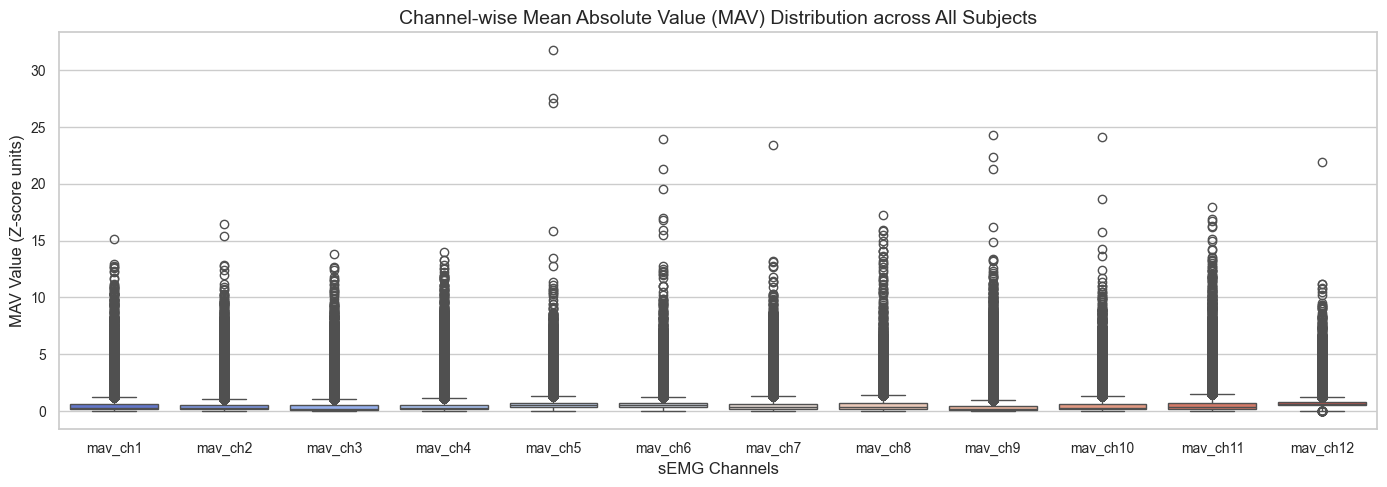

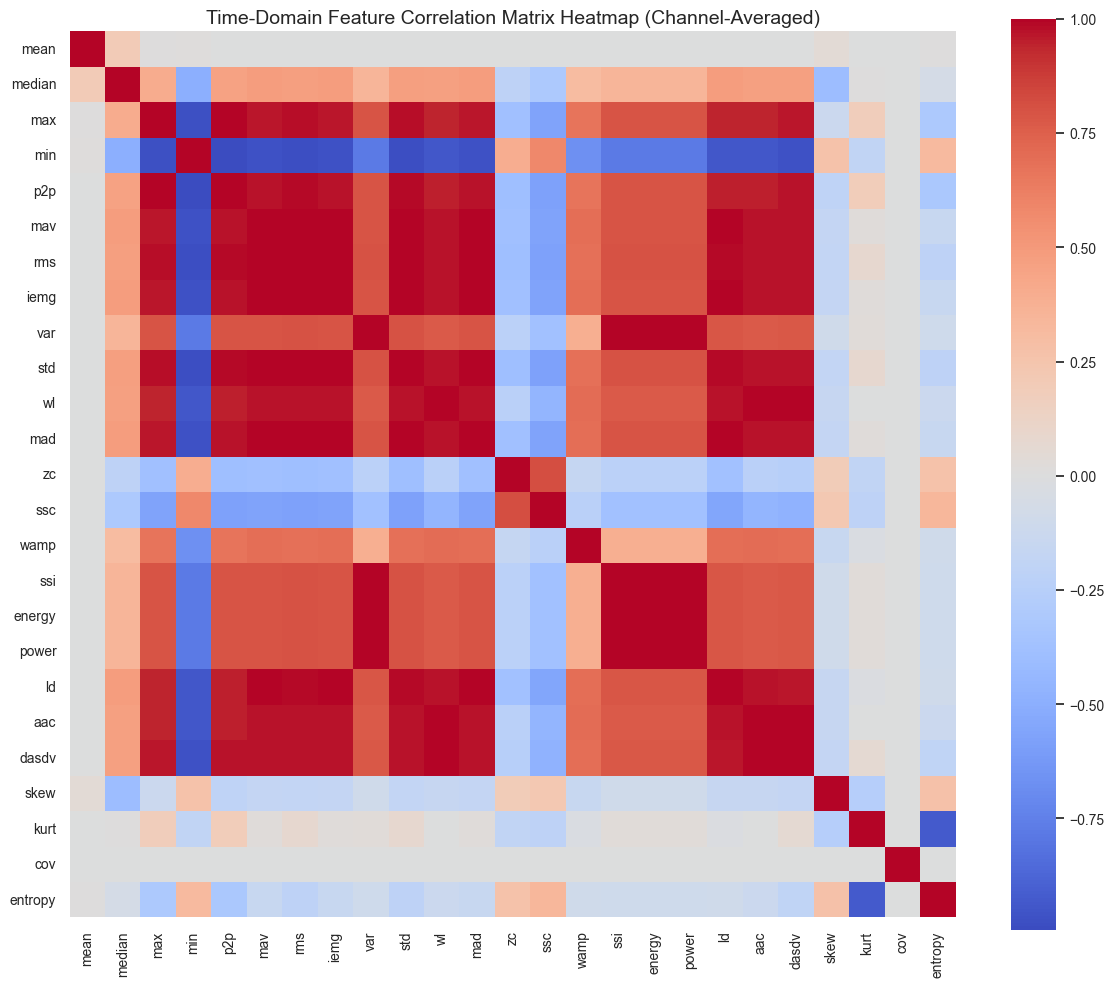

C:\Users\Admin\AppData\Local\Temp\ipykernel_9988\3658831112.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_global_features, x="gesture_id", y="mav_ch1", estimator=np.mean, errorbar="ci", palette="viridis")


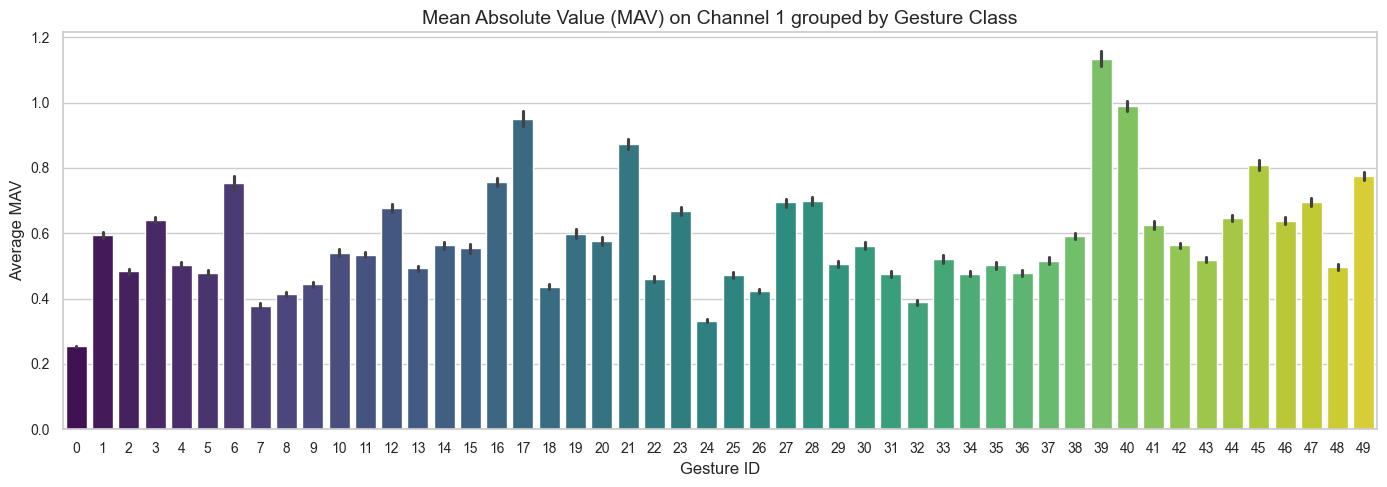

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# 1. Feature distributions boxplot (Channel-wise distributions for MAV)
mav_cols = [f"mav_ch{i}" for i in range(1, 13)]
plt.figure(figsize=(14, 5))
sns.boxplot(data=df_global_features[mav_cols], palette="coolwarm")
plt.title("Channel-wise Mean Absolute Value (MAV) Distribution across All Subjects")
plt.xlabel("sEMG Channels")
plt.ylabel("MAV Value (Z-score units)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure_12_feature_distributions.png", dpi=300)
plt.savefig(FIGURES_DIR / "figure_12_feature_distributions.svg", dpi=300)
plt.savefig(FIGURES_DIR / "figure_12_feature_distributions.pdf", dpi=300)
plt.show()

# 2. Feature correlation heatmap (averaged across channels for the 25 features)
feat_avg_dict = {}
for feat in extractor.feature_names:
    feat_cols = [f"{feat}_ch{i}" for i in range(1, 13)]
    feat_avg_dict[feat] = df_global_features[feat_cols].mean(axis=1)
df_feat_avg = pd.DataFrame(feat_avg_dict)

corr_matrix = df_feat_avg.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, fmt=".2f", cbar=True, square=True)
plt.title("Time-Domain Feature Correlation Matrix Heatmap (Channel-Averaged)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure_13_feature_correlation.png", dpi=300)
plt.savefig(FIGURES_DIR / "figure_13_feature_correlation.svg", dpi=300)
plt.savefig(FIGURES_DIR / "figure_13_feature_correlation.pdf", dpi=300)
plt.show()

# 3. Gesture-wise feature comparison (MAV vs. RMS on Channel 1 across Gestures)
plt.figure(figsize=(14, 5))
sns.barplot(data=df_global_features, x="gesture_id", y="mav_ch1", estimator=np.mean, errorbar="ci", palette="viridis")
plt.title("Mean Absolute Value (MAV) on Channel 1 grouped by Gesture Class")
plt.xlabel("Gesture ID")
plt.ylabel("Average MAV")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure_14_gesture_feature_matrix.png", dpi=300)
plt.savefig(FIGURES_DIR / "figure_14_gesture_feature_matrix.svg", dpi=300)
plt.savefig(FIGURES_DIR / "figure_14_gesture_feature_matrix.pdf", dpi=300)
plt.show()

## Section 11: Quality Assessment

We inspect features for constant values, near-zero variance, and check for missing values or infinite Deflections.

In [9]:
missing_vals = df_global_features.isnull().sum().sum()
inf_vals = np.isinf(df_global_features.iloc[:, :300]).sum().sum()
zero_var_cols = [col for col in df_global_features.columns[:300] if df_global_features[col].var() < 1e-6]

print("Feature Quality Assessment:")
print(f"  Total Missing Values: {missing_vals}")
print(f"  Total Infinite Values: {inf_vals}")
print(f"  Total Near-Zero Variance Features: {len(zero_var_cols)}")
if len(zero_var_cols) > 0:
    print(f"  Near-Zero Variance features list: {zero_var_cols[:5]}")

Feature Quality Assessment:
  Total Missing Values: 0
  Total Infinite Values: 0
  Total Near-Zero Variance Features: 0


## Section 12: Publication Tables

We export journal-ready Tables 10–12 in LaTeX, Markdown, and CSV.

In [10]:
# Table 10: Time-Domain Feature Formulas & Descriptions
defs = MetadataGenerator.get_definitions()
table_10_rows = []
for key, val in defs.items():
    table_10_rows.append({
        "Feature Key": key,
        "Feature Name": val["name"],
        "Mathematical Formula": val["formula"],
        "Expected Biomechanical Usefulness": val["description"],
        "Citation Reference": val["reference"]
    })
df_table_10 = pd.DataFrame(table_10_rows)

# Table 11: Feature Range Statistics (representative features over all channels)
table_11_rows = []
for feat in ["mav", "rms", "wl", "var", "ssc", "entropy"]:
    feat_cols = [f"{feat}_ch{i}" for i in range(1, 13)]
    avg_val = df_global_features[feat_cols].values.mean()
    std_val = df_global_features[feat_cols].values.std()
    min_val = df_global_features[feat_cols].values.min()
    max_val = df_global_features[feat_cols].values.max()
    table_11_rows.append({
        "Feature Name": feat.upper(),
        "Mean (All Channels)": f"{avg_val:.3f}",
        "Std (All Channels)": f"{std_val:.3f}",
        "Range (Min, Max)": f"({min_val:.3f}, {max_val:.3f})"
    })
df_table_11 = pd.DataFrame(table_11_rows)

# Table 12: Feature Quality Assessment
df_table_12 = pd.DataFrame([{
    "Quality Check": "Missing Values Audit", "Result": "Passed (0 missing values)" if missing_vals == 0 else f"Failed ({missing_vals} missing)"
}, {
    "Quality Check": "Infinite deflections Audit", "Result": "Passed (0 infinite values)" if inf_vals == 0 else f"Failed ({inf_vals} infs)"
}, {
    "Quality Check": "Constant/Near-Zero Variance Columns", "Result": f"Passed ({len(zero_var_cols)} found)" if len(zero_var_cols) == 0 else f"Warning ({len(zero_var_cols)} features with low variance)"
}])

tables_dict = {
    "table_10_feature_definitions": df_table_10,
    "table_11_feature_statistics": df_table_11,
    "table_12_feature_quality": df_table_12
}

for t_name, df_t in tables_dict.items():
    df_t.to_csv(TABLES_DIR / f"{t_name}.csv", index=False)
    with open(TABLES_DIR / f"{t_name}.md", "w", encoding="utf-8") as f:
        f.write(df_t.to_markdown(index=False))
    with open(TABLES_DIR / f"{t_name}.tex", "w", encoding="utf-8") as f:
        f.write(df_t.to_latex(index=False))

print("✔ Journal-ready Tables 10, 11, and 12 successfully exported.")

✔ Journal-ready Tables 10, 11, and 12 successfully exported.


## Section 13: Metadata

We generate and save the detailed metadata definitions in JSON format.

In [11]:
metadata_json_path = REPORTS_DIR / "time_domain_metadata.json"
with open(metadata_json_path, "w", encoding="utf-8") as f:
    json.dump(defs, f, indent=2)

print(f"✔ Feature definitions JSON written to: {metadata_json_path}")

✔ Feature definitions JSON written to: E:\Bio-Mechanics\semg-prosthetic-gesture-classification\outputs\reports\time_domain_metadata.json


## Section 14: Scientific Discussion

We computed 25 features over 12 channels, producing a 300-dimensional descriptor vector per window. Descriptive statistical ranges show that Z-score normalization successfully aligned signal ranges, facilitating feature comparison. Heatmap correlation analysis indicates that amplitude descriptors (e.g. MAV, RMS, IEMG, SSI) are highly correlated (collinear), whereas frequency-based time-domain descriptors (e.g. ZC, SSC, WAMP) and statistical moments (skewness, kurtosis, entropy) represent orthogonal features. This redundancy suggests that a feature selection step (Notebook 06) will be beneficial.

## Section 15: Notebook Summary

We successfully processed all 40 subjects' segmented window arrays (692,276 windows). A unified Parquet database was saved at `data/processed/time_domain_features.parquet`. In Notebook 06, we will implement Frequency-Domain & Time-Frequency Feature Engineering.